# mRMR Feature Selection by Time Window & KCL

1. ParkCeleb: run mRMR separately for each temporal window
2. KCL: run mRMR on the clinical dataset
3. Compare which features matter most at each stage

---

In [21]:
CYMO_PC      = '../ParkCeleb/ann.cymo_parkceleb_per_recording.csv'
META_PC      = './cymo_parkceleb_per_recording_metadata.csv'
TEMPORAL_CSV = '../ParkCeleb/temporal_analysis/target_recordings.csv'

CYMO_KCL_SD  = '../KCL/ann.cymo_kcl_dialogue_full.csv'
META_KCL_SD  = './cymo_kcl_dialogue_full_metadata.csv'

N_SELECT = 10  # top N features per window

In [22]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, warnings
from scipy import stats
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10, 'axes.titleweight': 'bold'})

In [23]:
# ============================================================
# mRMR function (reusable)
# ============================================================
def run_mrmr(df, feature_cols, label_col='label', n_select=10):
    """Run mRMR on a DataFrame. Returns list of (feature, relevance, redundancy, score)."""
    y = df[label_col].values
    
    # Relevance
    relevance = {}
    for f in feature_cols:
        vals = df[f].values
        if np.std(vals) < 1e-10:
            relevance[f] = 0
        else:
            rho, _ = stats.spearmanr(vals, y)
            relevance[f] = abs(rho) if not np.isnan(rho) else 0
    
    # Redundancy matrix
    #corr = df[feature_cols].corr(method='spearman').abs()
    #np.fill_diagonal(corr.values, 0)

    # Redundancy matrix
    corr = df[feature_cols].corr(method='spearman').abs()

    # Create a writeable copy, fill diagonal with 0, and reconstruct DataFrame
    corr_arr = corr.to_numpy().copy()
    np.fill_diagonal(corr_arr, 0)
    corr = pd.DataFrame(corr_arr, index=corr.index, columns=corr.columns)
    
    # Selection
    candidates = set(feature_cols)
    selected = []
    
    for step in range(min(n_select, len(feature_cols))):
        best_score, best_feat = -np.inf, None
        best_rel, best_red = 0, 0
        
        for feat in candidates:
            rel = relevance.get(feat, 0)
            red = corr.loc[feat, [s[0] for s in selected]].mean() if selected else 0
            score = rel - red
            if score > best_score:
                best_score, best_feat, best_rel, best_red = score, feat, rel, red
        
        if best_feat is None:
            break
        selected.append((best_feat, best_rel, best_red, best_score))
        candidates.remove(best_feat)
    
    return selected

---
## 1 — Load ParkCeleb with temporal data

In [24]:
# Load CYMO
cymo = pd.read_csv(CYMO_PC)
meta = pd.read_csv(META_PC)
temporal = pd.read_csv(TEMPORAL_CSV)

tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]
all_feature_cols = [c for c in cymo.columns if c != tid_col]

df = cymo.merge(meta[[meta_tid, 'group', 'subject', 'video_id']].drop_duplicates(),
                left_on=tid_col, right_on=meta_tid, how='inner')
df['label'] = (df['group'] == 'PD').astype(int)

for col in all_feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Clean features
missing = df[all_feature_cols].isnull().sum() / len(df)
feature_cols = [c for c in all_feature_cols if missing[c] <= 0.5]
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
feature_cols = [c for c in feature_cols if df[c].var() > 1e-10]

# Merge temporal
vid_col = 'video_id' if 'video_id' in temporal.columns else 'video_folder'
yrs_col = next((c for c in temporal.columns if 'years' in c.lower()), None)
ba_col = next((c for c in temporal.columns if 'before_after' in c.lower()), None)

merge_temp = temporal[['subject', vid_col, yrs_col, ba_col]].drop_duplicates()
if vid_col != 'video_id':
    merge_temp = merge_temp.rename(columns={vid_col: 'video_id'})

df = df.loc[:, ~df.columns.duplicated()]
df = df.merge(merge_temp, on=['subject', 'video_id'], how='left')

# Create signed years
df[yrs_col] = pd.to_numeric(df[yrs_col], errors='coerce')
ba_lower = df[ba_col].astype(str).str.strip().str.lower()
df['signed_years'] = df[yrs_col]
df.loc[ba_lower == 'before', 'signed_years'] = -df[yrs_col]
df.loc[ba_lower == 'same', 'signed_years'] = 0

has_time = df['signed_years'].notna()
print(f'ParkCeleb: {len(df)} recordings, {len(feature_cols)} features')
print(f'Recordings with temporal data: {has_time.sum()}')
print(f'PD recordings with temporal data: {(has_time & (df["label"]==1)).sum()}')

ParkCeleb: 143941 recordings, 344 features
Recordings with temporal data: 48301
PD recordings with temporal data: 24554


---
## 2 — mRMR by temporal window (PD vs CN at each time period)

In [25]:
# ============================================================
# 2.1  Define time windows and run mRMR for each
# ============================================================

# For each window: take PD recordings in that time range + ALL CN recordings
# (CN subjects have no diagnosis date, so they're always the reference group)

windows = [
    ('6-10yr pre',  -10, -5),
    ('1-5yr pre',   -5,  -1),
    ('1-5yr post',   0,   5),
    ('6-10yr post',  5,  10),
    ('11-30yr post', 10, 30),
]

cn_recs = df[df['label'] == 0]  # all CN recordings as reference

window_results = {}

for win_name, lo, hi in windows:
    # PD recordings in this time window
    pd_mask = (df['label'] == 1) & (df['signed_years'] >= lo) & (df['signed_years'] < hi)
    pd_recs = df[pd_mask]
    
    if len(pd_recs) < 10:
        print(f'{win_name}: only {len(pd_recs)} PD recordings, skipping')
        continue
    
    # Combine PD window + all CN
    subset = pd.concat([cn_recs, pd_recs], ignore_index=True)
    
    # Run mRMR
    selected = run_mrmr(subset, feature_cols, n_select=N_SELECT)
    window_results[win_name] = {
        'features': selected,
        'n_pd': len(pd_recs),
        'n_cn': len(cn_recs),
    }
    
    print(f'\n{win_name} ({len(pd_recs)} PD + {len(cn_recs)} CN recordings):')
    print(f'  {"#":<4s} {"Feature":<40s} {"Relevance":>10s} {"Redundancy":>11s} {"Score":>8s}')
    print(f'  {"─"*75}')
    for i, (feat, rel, red, score) in enumerate(selected):
        print(f'  {i+1:<4d} {feat:<40s} {rel:>10.4f} {red:>11.4f} {score:>8.4f}')


6-10yr pre (2820 PD + 80252 CN recordings):
  #    Feature                                   Relevance  Redundancy    Score
  ───────────────────────────────────────────────────────────────────────────
  1    T100KCOCAw                                   0.0811      0.0000   0.0811
  2    DPCOCAs                                      0.0349      0.0121   0.0228
  3    N2SAOsn                                      0.0110      0.0027   0.0083
  4    TOPspo                                       0.0392      0.0323   0.0069
  5    EMOann                                       0.0184      0.0134   0.0050
  6    EMObli                                       0.0093      0.0084   0.0009
  7    NSAOb                                        0.0632      0.0543   0.0089
  8    QUANTmn                                      0.0037      0.0047  -0.0010
  9    CONJspur                                     0.0074      0.0079  -0.0005
  10   PRNref2s                                     0.0058      0.0070  -0.00

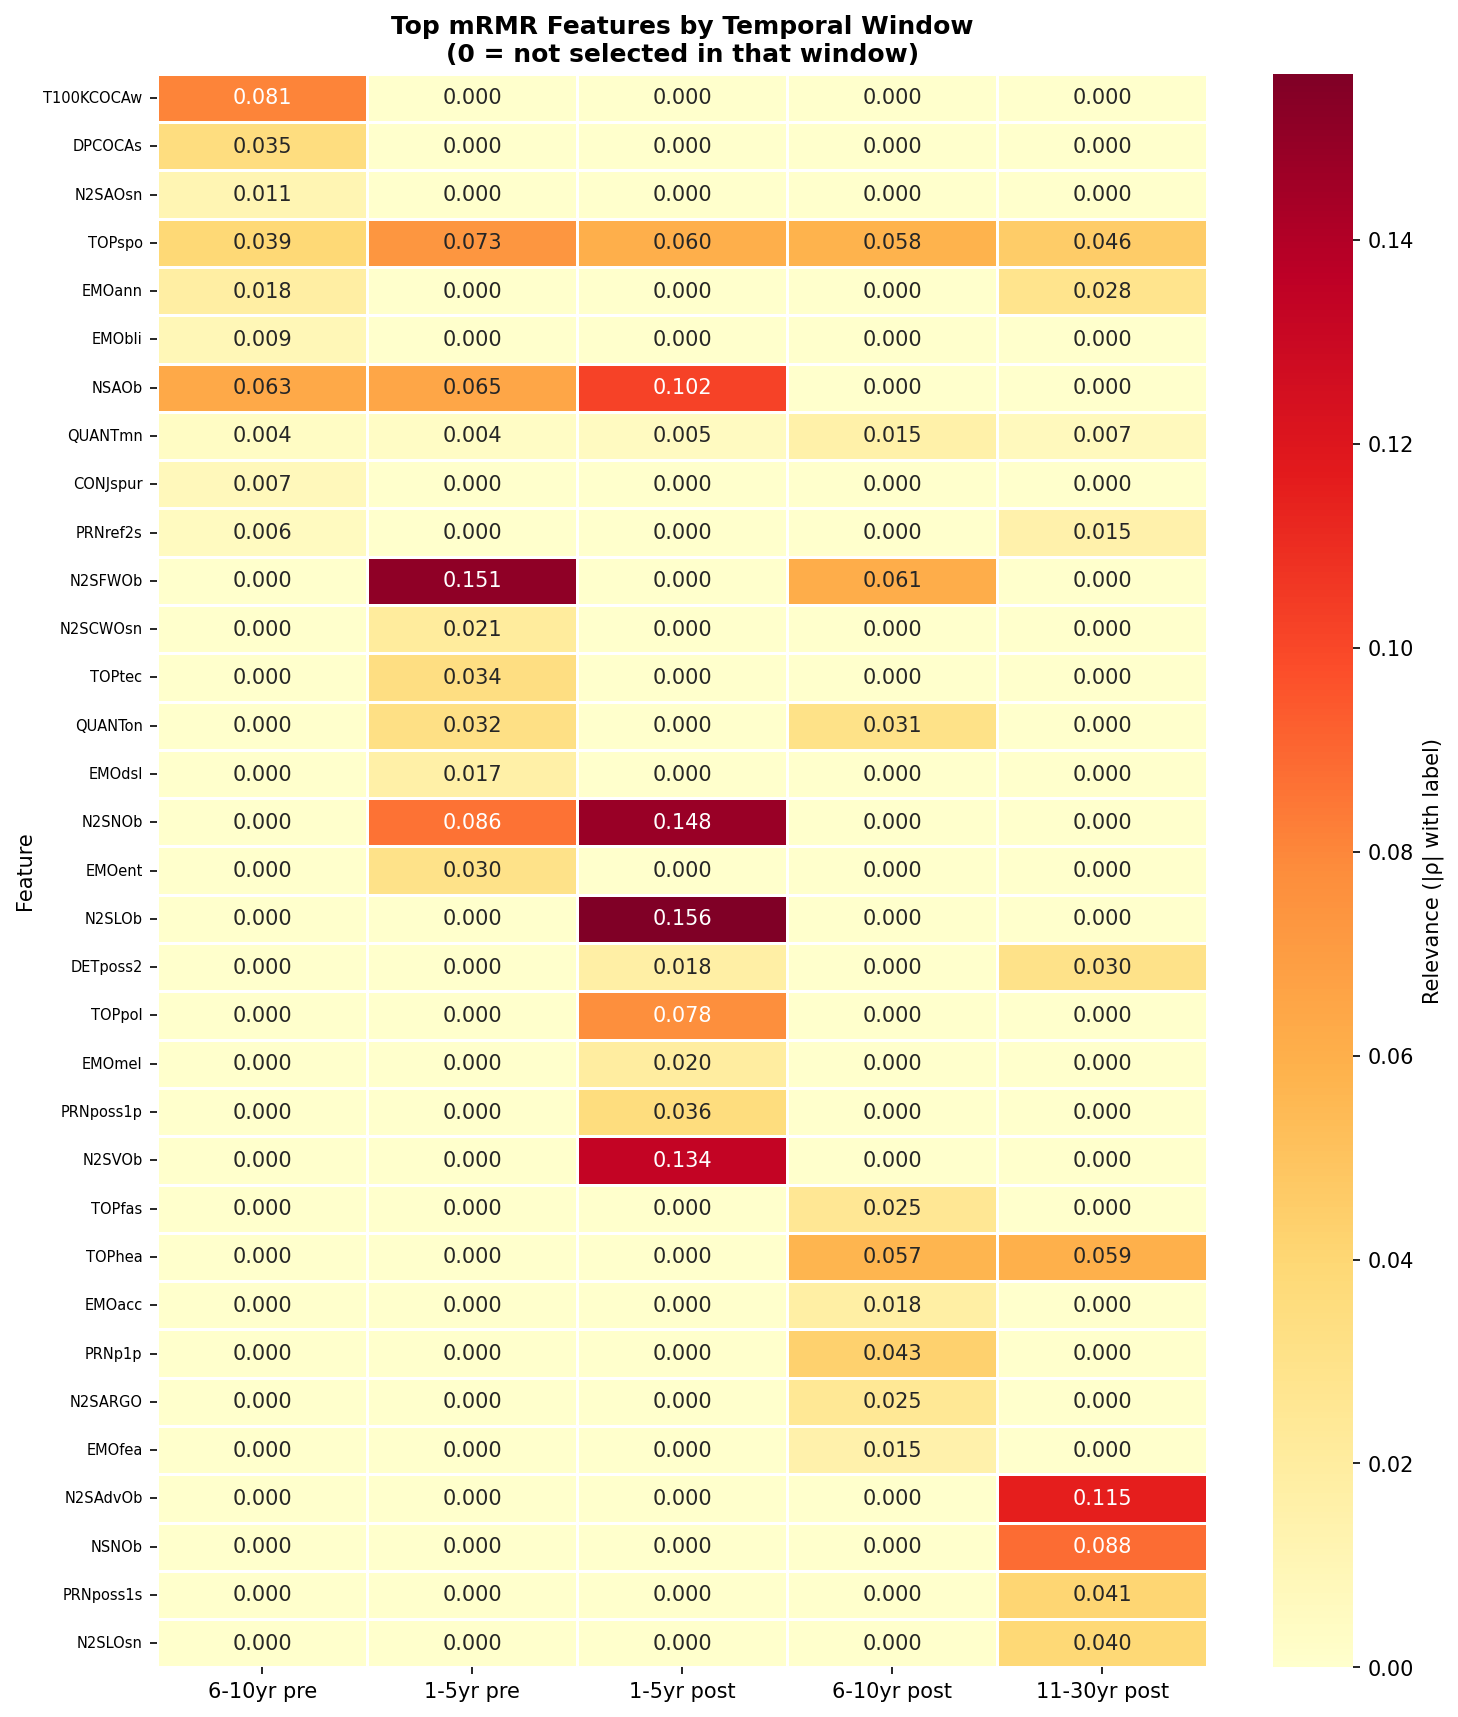

In [26]:
# ============================================================
# 2.2  Heatmap: which features appear in which windows
# ============================================================
all_top_feats = []
for win_name, data in window_results.items():
    for feat, rel, red, score in data['features']:
        if feat not in all_top_feats:
            all_top_feats.append(feat)

# Build matrix: rows = features, columns = time windows
win_names = list(window_results.keys())
matrix = pd.DataFrame(0.0, index=all_top_feats, columns=win_names)

for win_name, data in window_results.items():
    for rank, (feat, rel, red, score) in enumerate(data['features']):
        matrix.loc[feat, win_name] = rel  # use relevance as the value

fig, ax = plt.subplots(figsize=(10, max(6, len(all_top_feats) * 0.35)))
sns.heatmap(matrix, cmap='YlOrRd', annot=True, fmt='.3f', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Relevance (|ρ| with label)'})
ax.set_title(f'Top mRMR Features by Temporal Window\n(0 = not selected in that window)')
ax.set_ylabel('Feature')
ax.tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig('mrmr_temporal_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

In [27]:
# ============================================================
# 2.3  Rank comparison table
# ============================================================
print(f'\nFEATURE RANK BY TIME WINDOW')
#print(f'({"—" = not in top {N_SELECT}})')
print(f'(— = not in top {N_SELECT})')
print(f'\n{"Feature":<40s}', end='')
for wn in win_names:
    print(f' {wn:>12s}', end='')
print()
print('─' * (40 + 13 * len(win_names)))

for feat in all_top_feats:
    print(f'{feat:<40s}', end='')
    for win_name in win_names:
        # Find rank of this feature in this window
        feats_in_win = [f for f, _, _, _ in window_results[win_name]['features']]
        if feat in feats_in_win:
            rank = feats_in_win.index(feat) + 1
            print(f' {rank:>12d}', end='')
        else:
            print(f' {"—":>12s}', end='')
    print()

# Count how many windows each feature appears in
print(f'\nFeatures appearing in ALL windows:')
for feat in all_top_feats:
    count = sum(1 for wn in win_names
                if feat in [f for f, _, _, _ in window_results[wn]['features']])
    if count == len(win_names):
        print(f'  ★ {feat}')


FEATURE RANK BY TIME WINDOW
(— = not in top 10)

Feature                                    6-10yr pre    1-5yr pre   1-5yr post  6-10yr post 11-30yr post
─────────────────────────────────────────────────────────────────────────────────────────────────────────
T100KCOCAw                                          1            —            —            —            —
DPCOCAs                                             2            —            —            —            —
N2SAOsn                                             3            —            —            —            —
TOPspo                                              4            3            5            9           10
EMOann                                              5            —            —            —            4
EMObli                                              6            —            —            —            —
NSAOb                                               7            6            4            —          

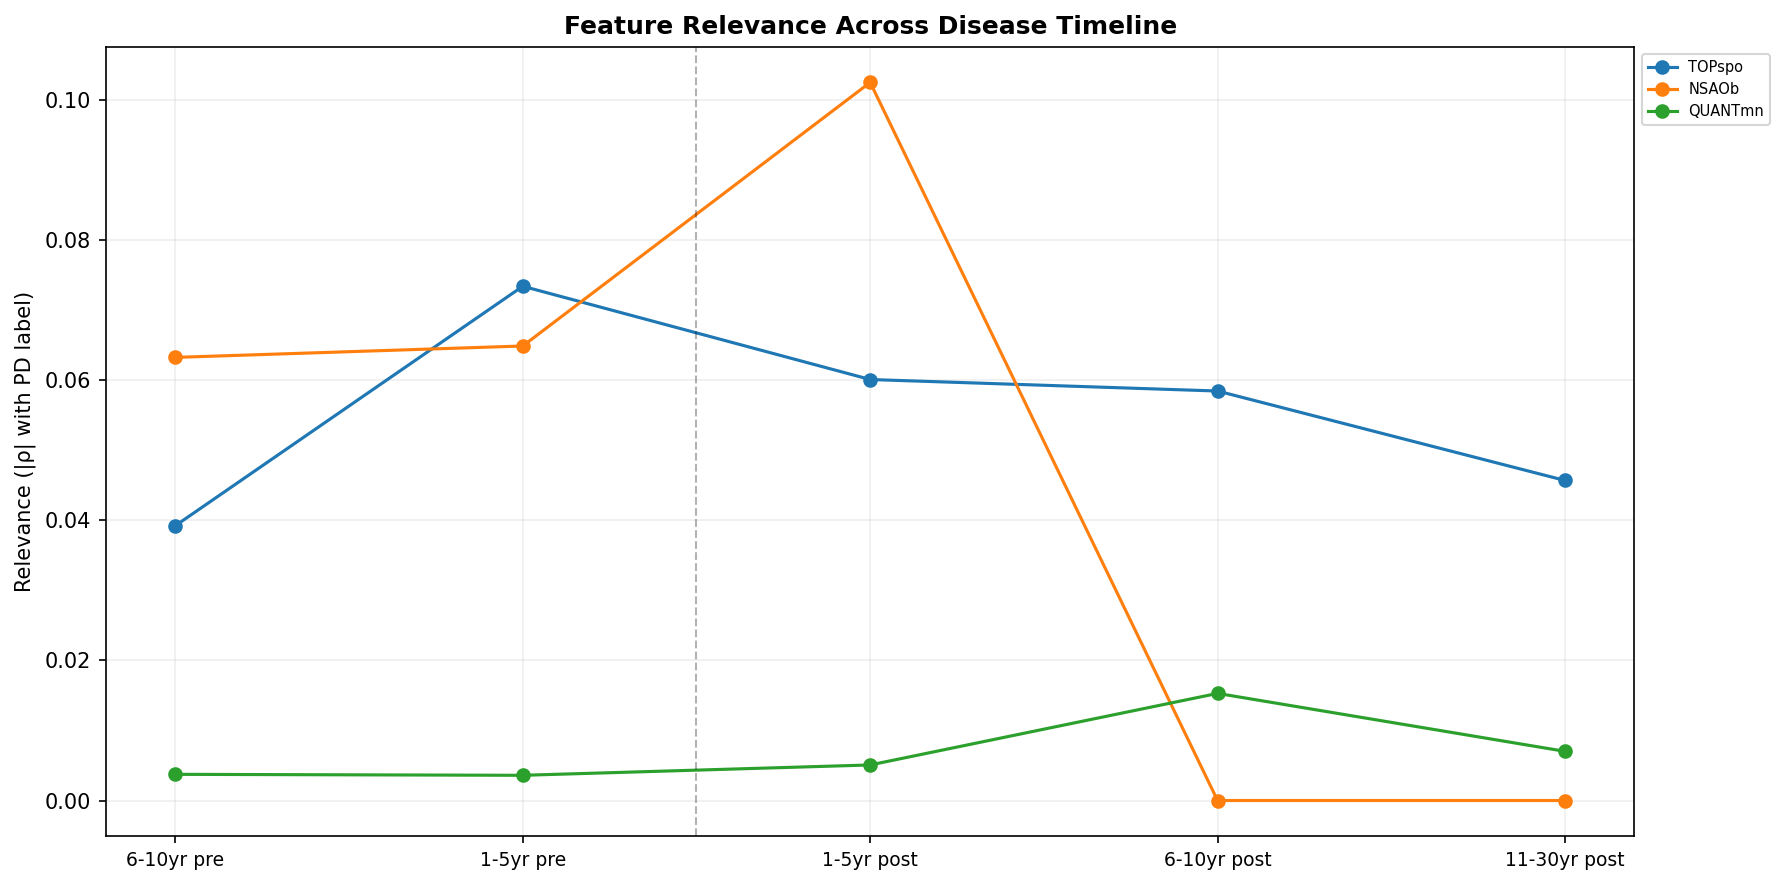

In [28]:
# ============================================================
# 2.4  Relevance progression: how each feature's relevance changes over time
# ============================================================
# Pick features that appear in at least 3 windows
frequent_feats = []
for feat in all_top_feats:
    count = sum(1 for wn in win_names
                if feat in [f for f, _, _, _ in window_results[wn]['features']])
    if count >= 3:
        frequent_feats.append(feat)

if frequent_feats:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for feat in frequent_feats:
        rels = []
        for wn in win_names:
            found = [rel for f, rel, _, _ in window_results[wn]['features'] if f == feat]
            rels.append(found[0] if found else 0)
        ax.plot(range(len(win_names)), rels, 'o-', label=feat, markersize=6, linewidth=1.5)
    
    ax.set_xticks(range(len(win_names)))
    ax.set_xticklabels(win_names, fontsize=9)
    ax.set_ylabel('Relevance (|ρ| with PD label)')
    ax.set_title('Feature Relevance Across Disease Timeline')
    ax.legend(fontsize=7, loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(alpha=0.2)
    ax.axvline(1.5, color='black', ls='--', lw=1, alpha=0.3, label='Diagnosis')
    
    plt.tight_layout()
    plt.savefig('mrmr_temporal_progression.png', dpi=200, bbox_inches='tight')
    plt.show()
else:
    print('No features appeared in 3+ windows')

---
## 3 — mRMR on KCL dataset

In [29]:
# ============================================================
# 3.1  Load KCL CYMO data
# ============================================================
import os

if os.path.isfile(CYMO_KCL_SD) and os.path.isfile(META_KCL_SD):
    kcl_cymo = pd.read_csv(CYMO_KCL_SD)
    kcl_meta = pd.read_csv(META_KCL_SD)
    
    tc = 'TID' if 'TID' in kcl_cymo.columns else kcl_cymo.columns[0]
    mc = 'TID' if 'TID' in kcl_meta.columns else kcl_meta.columns[0]
    sc = next((c for c in kcl_meta.columns if c in ('subject', 'subject_id')), None)
    
    kcl = kcl_cymo.merge(kcl_meta[[mc, 'group', sc]].drop_duplicates(),
                          left_on=tc, right_on=mc, how='inner')
    if sc != 'subject':
        kcl = kcl.rename(columns={sc: 'subject'})
    kcl['group'] = kcl['group'].replace({'HC': 'CN'})
    kcl['label'] = (kcl['group'] == 'PD').astype(int)
    kcl = kcl.loc[:, ~kcl.columns.duplicated()]
    
    kcl_feat_cols = [c for c in kcl_cymo.columns if c != tc]
    for col in kcl_feat_cols:
        kcl[col] = pd.to_numeric(kcl[col], errors='coerce')
    
    missing = kcl[kcl_feat_cols].isnull().sum() / len(kcl)
    kcl_feat_cols = [c for c in kcl_feat_cols if missing[c] <= 0.5]
    kcl[kcl_feat_cols] = kcl[kcl_feat_cols].fillna(kcl[kcl_feat_cols].median())
    kcl_feat_cols = [c for c in kcl_feat_cols if kcl[c].var() > 1e-10]
    
    print(f'KCL Dialogue: {len(kcl)} recordings, {kcl["subject"].nunique()} subjects')
    print(f'  CN: {kcl[kcl["label"]==0]["subject"].nunique()}  PD: {kcl[kcl["label"]==1]["subject"].nunique()}')
    print(f'  Usable features: {len(kcl_feat_cols)}')
else:
    print('KCL files not found')
    kcl = None

KCL Dialogue: 573 recordings, 36 subjects
  CN: 21  PD: 15
  Usable features: 336


In [30]:
# ============================================================
# 3.2  Run mRMR on KCL
# ============================================================
if kcl is not None:
    #kcl_selected = run_mrmr(kcl, kcl_feat_cols, n_select=N_SELECT)
    kcl_selected = run_mrmr(kcl, kcl_feat_cols, n_select=24)
    
    print(f'KCL mRMR Top {N_SELECT} Features:\n')
    print(f'{"#":<4s} {"Feature":<40s} {"Relevance":>10s} {"Redundancy":>11s} {"Score":>8s}')
    print('─' * 75)
    for i, (feat, rel, red, score) in enumerate(kcl_selected):
        print(f'{i+1:<4d} {feat:<40s} {rel:>10.4f} {red:>11.4f} {score:>8.4f}')

KCL mRMR Top 10 Features:

#    Feature                                   Relevance  Redundancy    Score
───────────────────────────────────────────────────────────────────────────
1    NSLOb                                        0.5170      0.0000   0.5170
2    EMOsur                                       0.0987      0.0235   0.0753
3    N2SPOb                                       0.4642      0.3726   0.0917
4    T100KCOCAs                                   0.1364      0.0620   0.0744
5    NSFWOb                                       0.4725      0.4210   0.0515
6    PREPc                                        0.0557      0.0097   0.0460
7    PRNposs3s                                    0.1149      0.0669   0.0481
8    N2SLOb                                       0.4578      0.3625   0.0953
9    QUANTcn                                      0.1208      0.0786   0.0423
10   N2SARGOb                                     0.4643      0.3923   0.0721
11   NSAdvOb                           

In [31]:
# ============================================================
# 3.3  Compare KCL features vs ParkCeleb overall features
# ============================================================
# Run mRMR on all ParkCeleb (no time filter) for comparison
pc_selected = run_mrmr(df, feature_cols, n_select=N_SELECT)

pc_feats = [f for f, _, _, _ in pc_selected]
kcl_feats = [f for f, _, _, _ in kcl_selected] if kcl is not None else []

shared = set(pc_feats) & set(kcl_feats)
only_pc = set(pc_feats) - set(kcl_feats)
only_kcl = set(kcl_feats) - set(pc_feats)

print(f'ParkCeleb vs KCL mRMR Comparison')
print(f'={"="*50}')
print(f'  Shared ({len(shared)}): {", ".join(sorted(shared)) if shared else "none"}')
print(f'  Only ParkCeleb ({len(only_pc)}): {", ".join(sorted(only_pc))}')
print(f'  Only KCL ({len(only_kcl)}): {", ".join(sorted(only_kcl))}')

# Side by side
print(f'\n{"Rank":<5s} {"ParkCeleb":<40s} {"KCL":<40s}')
print('─' * 85)
for i in range(N_SELECT):
    pc_f = pc_feats[i] if i < len(pc_feats) else ''
    kcl_f = kcl_feats[i] if i < len(kcl_feats) else ''
    marker = ' ★' if pc_f == kcl_f and pc_f else ''
    print(f'{i+1:<5d} {pc_f:<40s} {kcl_f:<40s}{marker}')

ParkCeleb vs KCL mRMR Comparison
  Shared (2): N2SLOb, NSLOb
  Only ParkCeleb (8): DETposs2, NSAOb, PRNposs1p, PRNposs1s, T50KCOCAw, TOPent, TOPhea, lwVAR
  Only KCL (22): CONJspur, DETposs3s, EMOanx, EMOcal, EMOsur, N2SARGOb, N2SFWOb, N2SPOb, NSARGOb, NSAdvOb, NSFWOb, NSLO, NSPOb, NSVOb, PREPc, PRNposs3s, PRNref1s, PRNref3s, QUANTcn, T100KCOCAs, VCCOCAs, wid

Rank  ParkCeleb                                KCL                                     
─────────────────────────────────────────────────────────────────────────────────────
1     N2SLOb                                   NSLOb                                   
2     lwVAR                                    EMOsur                                  
3     TOPhea                                   N2SPOb                                  
4     PRNposs1p                                T100KCOCAs                              
5     NSAOb                                    NSFWOb                                  
6     TOPent           

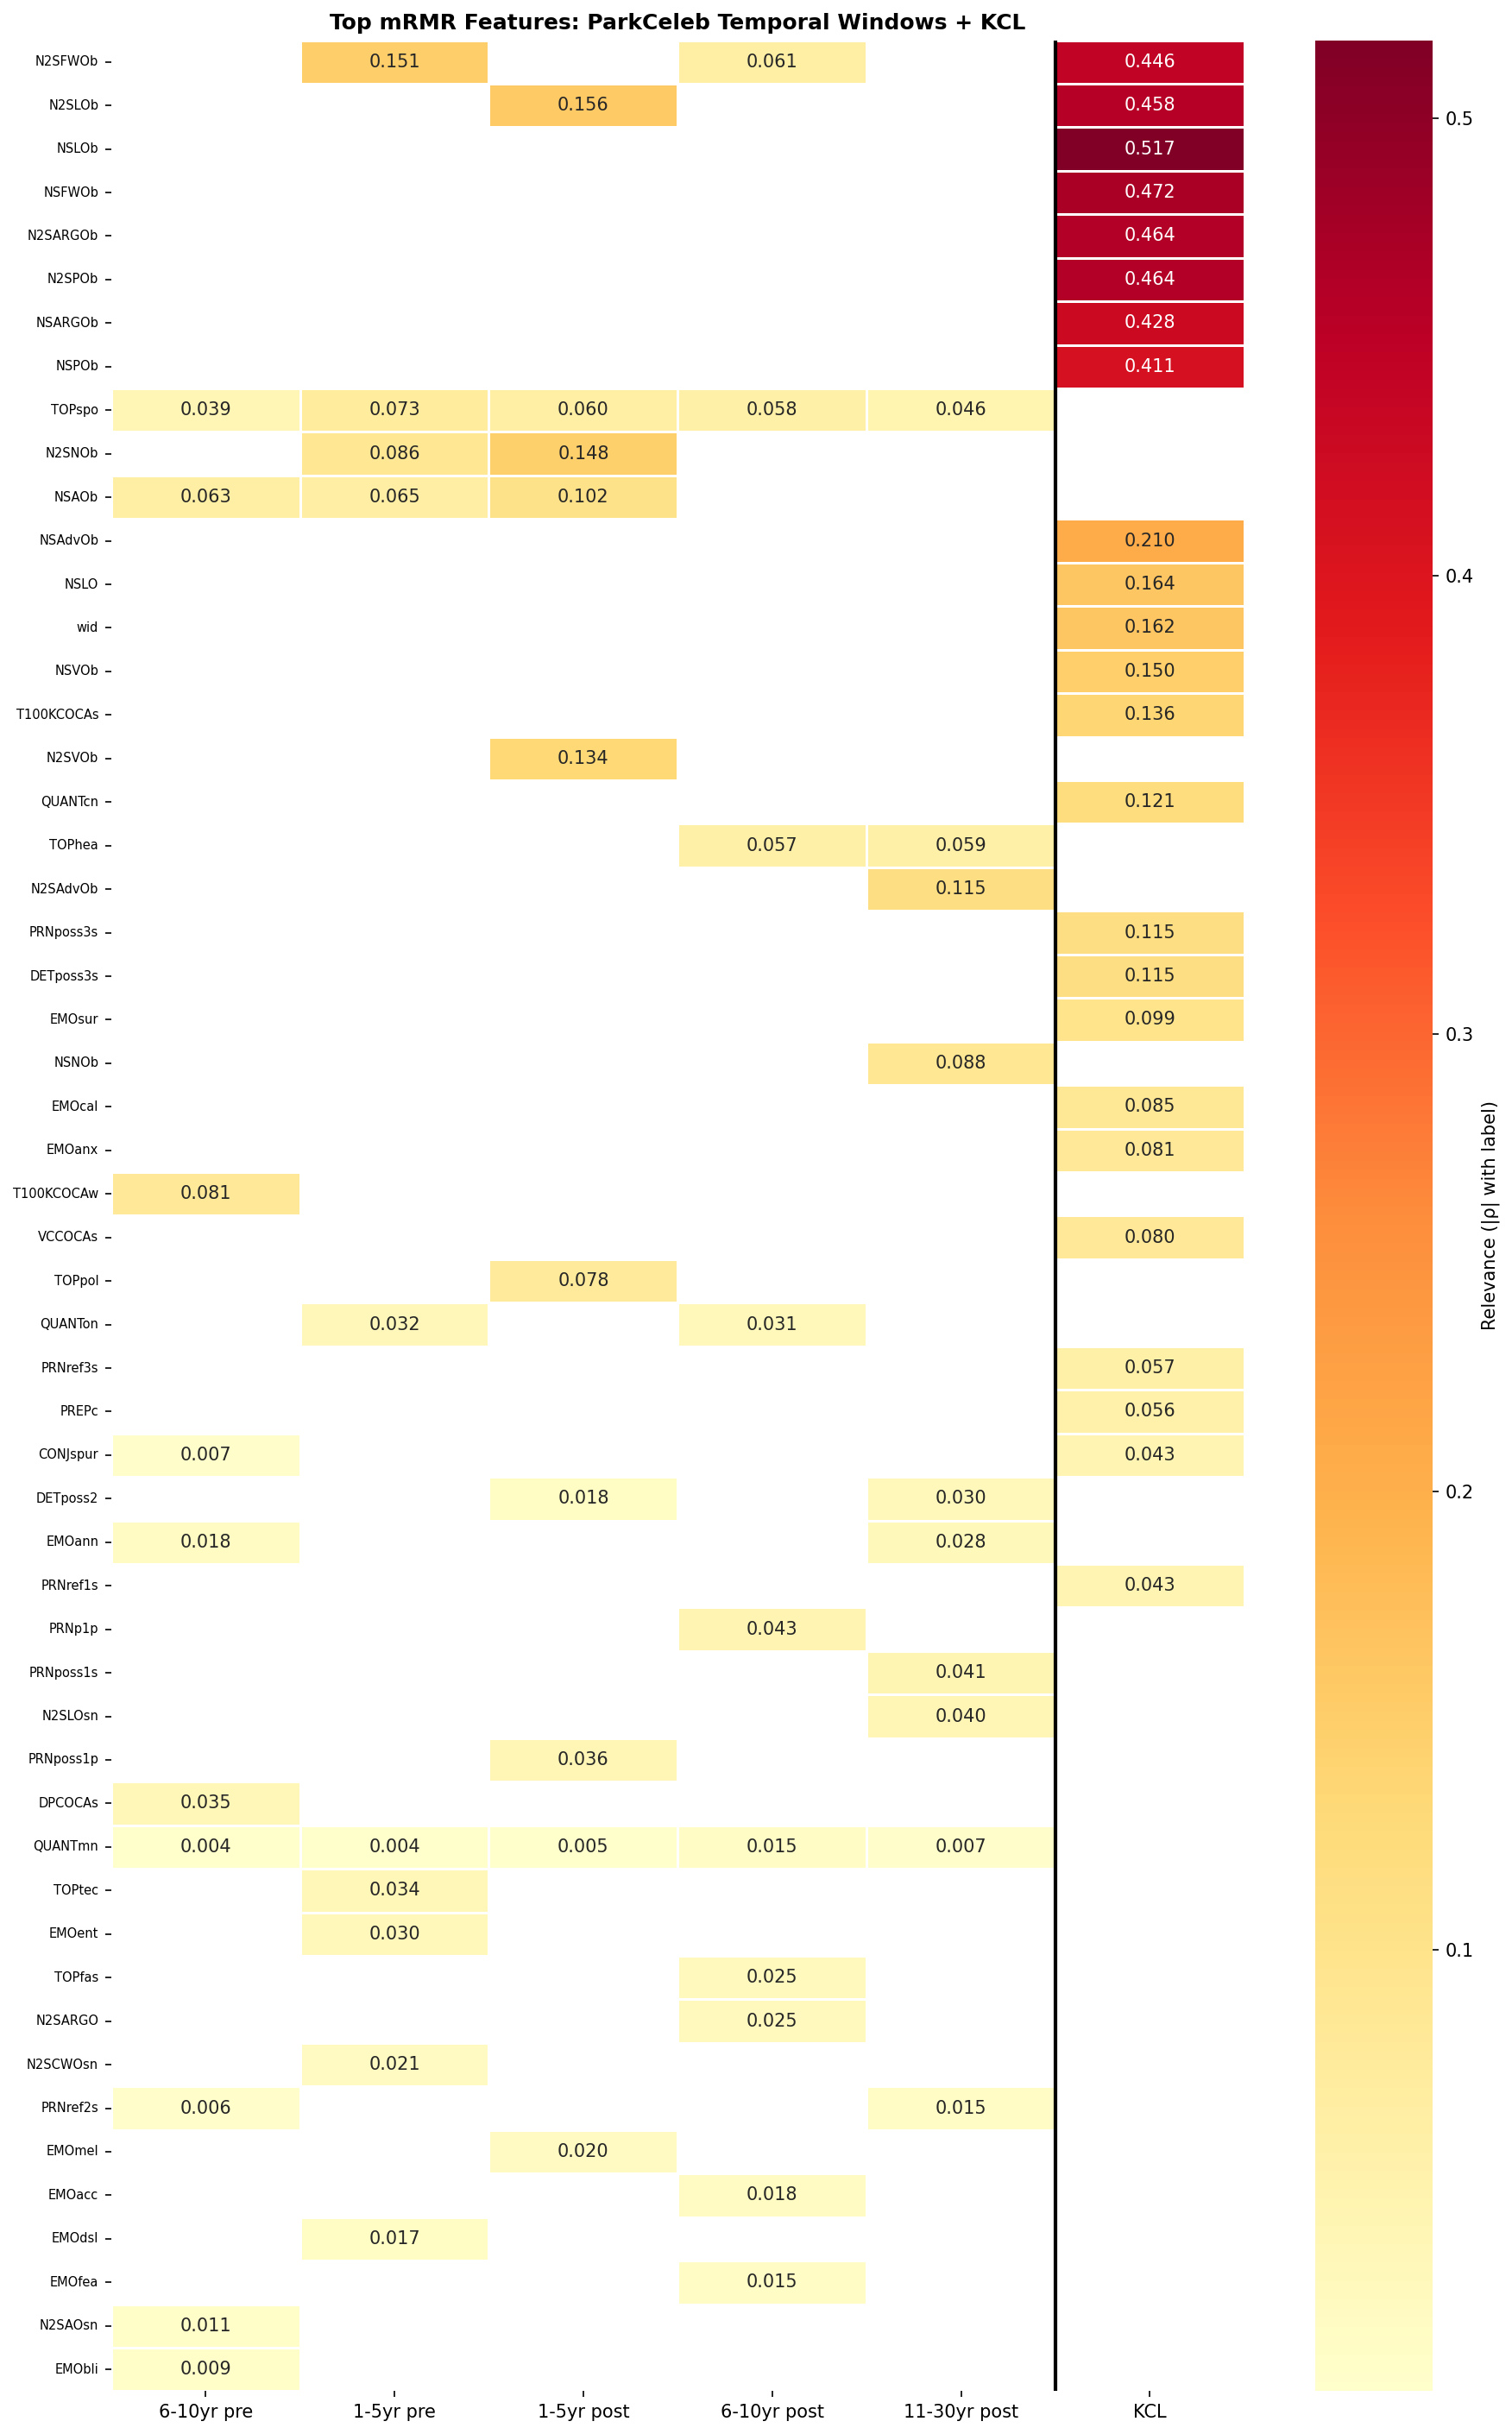

In [32]:
# ============================================================
# 3.4  Combined heatmap: all windows + KCL
# ============================================================
all_feats_combined = list(all_top_feats)
if kcl is not None:
    for f, _, _, _ in kcl_selected:
        if f not in all_feats_combined:
            all_feats_combined.append(f)

col_names = win_names + ['KCL']
matrix2 = pd.DataFrame(0.0, index=all_feats_combined, columns=col_names)

for win_name, data in window_results.items():
    for feat, rel, _, _ in data['features']:
        matrix2.loc[feat, win_name] = rel

if kcl is not None:
    for feat, rel, _, _ in kcl_selected:
        matrix2.loc[feat, 'KCL'] = rel

# Sort by total relevance across all columns
matrix2['total'] = matrix2.sum(axis=1)
matrix2 = matrix2.sort_values('total', ascending=False).drop(columns='total')

fig, ax = plt.subplots(figsize=(12, max(6, len(matrix2) * 0.35)))
sns.heatmap(matrix2, cmap='YlOrRd', annot=True, fmt='.3f', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Relevance (|ρ| with label)'},
            mask=(matrix2 == 0))  # hide zeros
ax.set_title(f'Top mRMR Features: ParkCeleb Temporal Windows + KCL')
ax.tick_params(axis='y', labelsize=7)

# Add vertical line separating PC windows from KCL
ax.axvline(len(win_names), color='black', lw=2)

plt.tight_layout()
plt.savefig('mrmr_temporal_plus_kcl_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

In [33]:
# ============================================================
# 4.  Save all results
# ============================================================
# Temporal results
temporal_rows = []
for win_name, data in window_results.items():
    for rank, (feat, rel, red, score) in enumerate(data['features']):
        temporal_rows.append({
            'window': win_name, 'rank': rank+1, 'feature': feat,
            'relevance': rel, 'redundancy': red, 'mrmr_score': score,
            'n_pd': data['n_pd'], 'n_cn': data['n_cn'],
        })
pd.DataFrame(temporal_rows).to_csv('mrmr_temporal_features.csv', index=False)
print('Saved: mrmr_temporal_features.csv')

# KCL results
if kcl is not None:
    kcl_rows = [{'rank': i+1, 'feature': f, 'relevance': r, 'redundancy': rd, 'mrmr_score': s}
                for i, (f, r, rd, s) in enumerate(kcl_selected)]
    pd.DataFrame(kcl_rows).to_csv('mrmr_kcl_features.csv', index=False)
    print('Saved: mrmr_kcl_features.csv')

Saved: mrmr_temporal_features.csv
Saved: mrmr_kcl_features.csv


Top 15 mRMR Features: ParkCeleb vs KCL
  Shared       : 2 / 15
  Only ParkCeleb: 13
  Only KCL      : 13

Rank  ParkCeleb                                ρ   KCL                                      ρ  Match
────────────────────────────────────────────────────────────────────────────────────────────────────
1     N2SLOb                              0.2106   NSLOb                               0.5170      ✓
2     lwVAR                               0.0284   EMOsur                              0.0987       
3     TOPhea                              0.0702   N2SPOb                              0.4642       
4     PRNposs1p                           0.0473   T100KCOCAs                          0.1364       
5     NSAOb                               0.0789   NSFWOb                              0.4725       
6     TOPent                              0.0493   PREPc                               0.0557       
7     T50KCOCAw                           0.0808   PRNposs3s                          

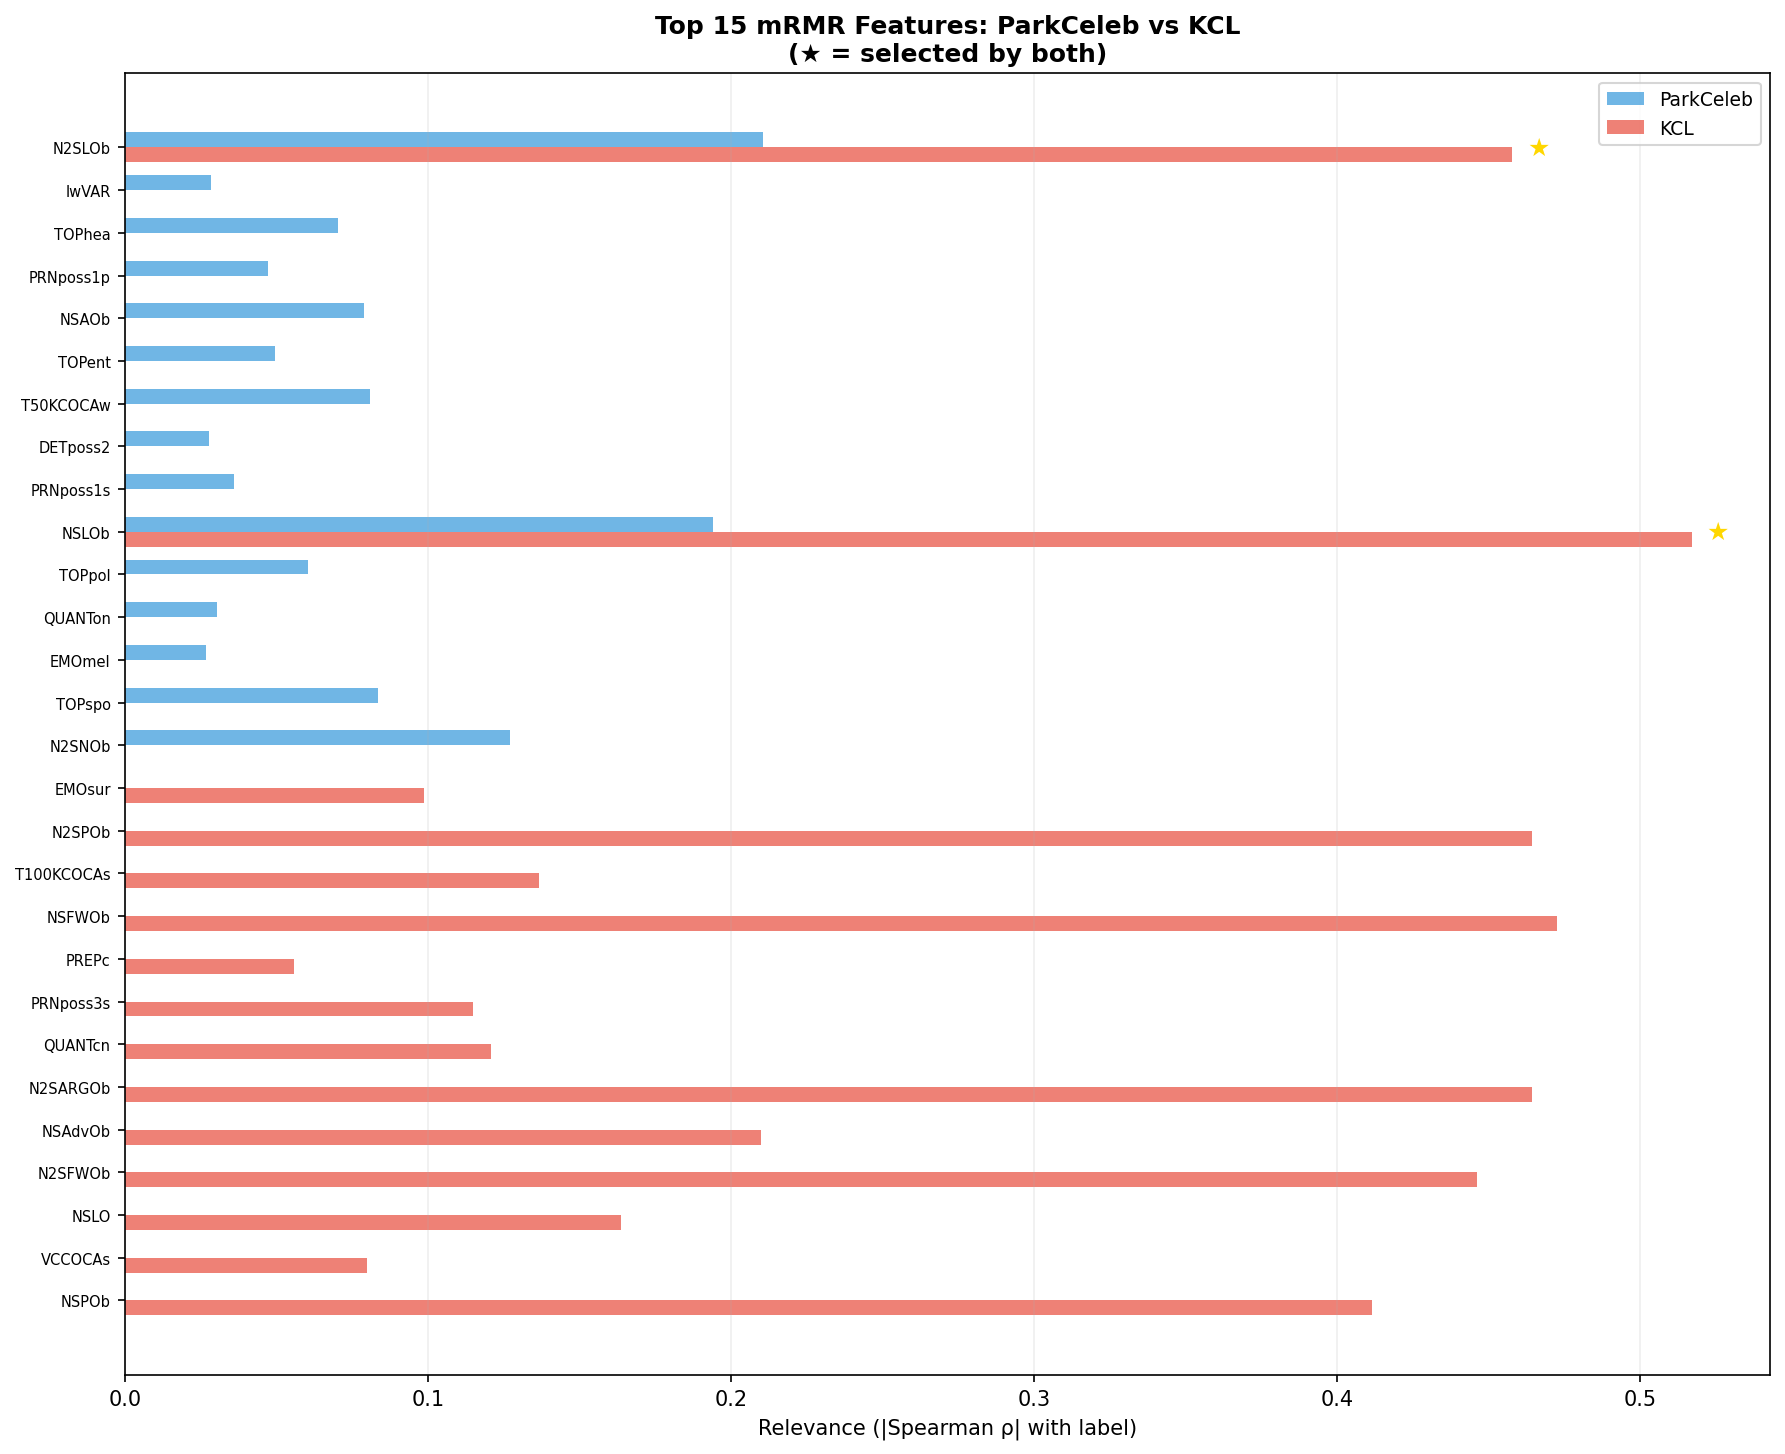

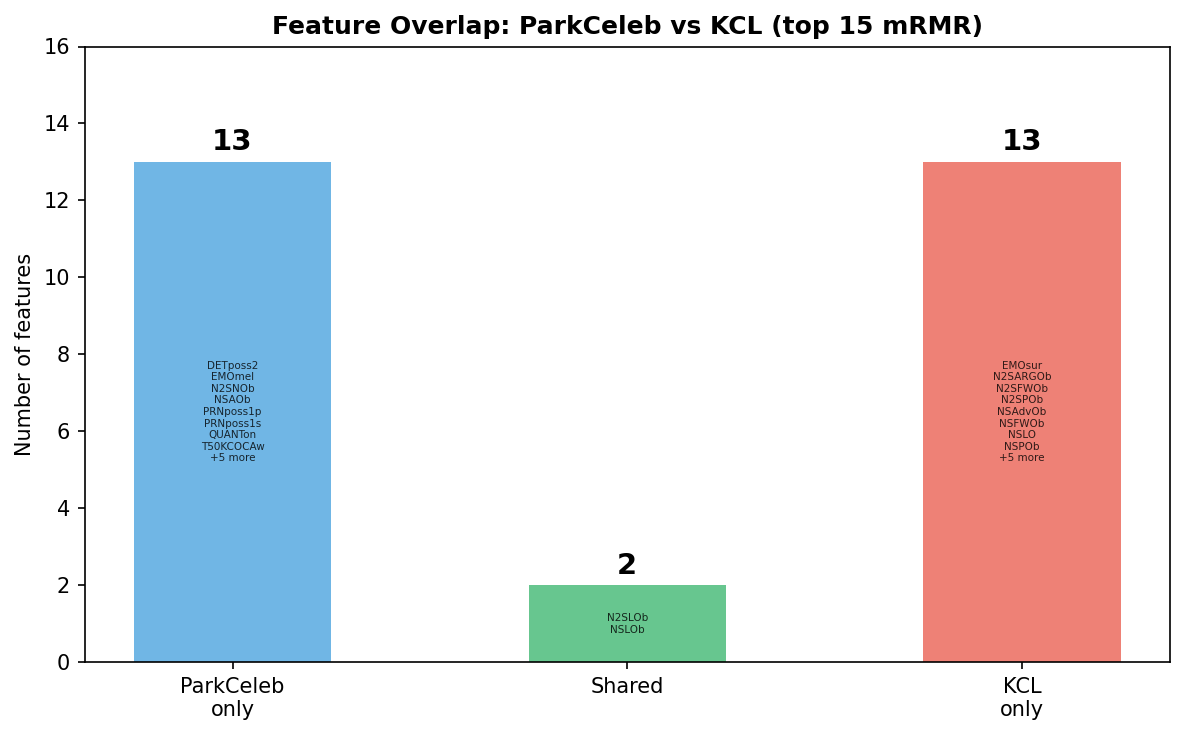

In [34]:
# ============================================================
# 5.  Compare top N mRMR features: ParkCeleb vs KCL
# ============================================================

# ╔══════════════════════════════════════════════════════════╗
# ║  ADJUST N HERE                                          ║
# ╚══════════════════════════════════════════════════════════╝
N_COMPARE = 15

# Re-run mRMR with N_COMPARE for both datasets
pc_top = run_mrmr(df, feature_cols, n_select=N_COMPARE)
kcl_top = run_mrmr(kcl, kcl_feat_cols, n_select=N_COMPARE) if kcl is not None else []

pc_names = [f for f, _, _, _ in pc_top]
kcl_names = [f for f, _, _, _ in kcl_top]

shared = set(pc_names) & set(kcl_names)
only_pc = set(pc_names) - set(kcl_names)
only_kcl = set(kcl_names) - set(pc_names)

print(f'Top {N_COMPARE} mRMR Features: ParkCeleb vs KCL')
print(f'{"="*70}')
print(f'  Shared       : {len(shared)} / {N_COMPARE}')
print(f'  Only ParkCeleb: {len(only_pc)}')
print(f'  Only KCL      : {len(only_kcl)}')

# Side by side with relevance
print(f'\n{"Rank":<5s} {"ParkCeleb":<35s} {"ρ":>6s}   {"KCL":<35s} {"ρ":>6s}  {"Match":>5s}')
print('─' * 100)
for i in range(N_COMPARE):
    pc_f, pc_r = (pc_names[i], pc_top[i][1]) if i < len(pc_top) else ('', 0)
    kcl_f, kcl_r = (kcl_names[i], kcl_top[i][1]) if i < len(kcl_top) else ('', 0)
    match = '★' if pc_f == kcl_f else ('✓' if pc_f in kcl_names or kcl_f in pc_names else '')
    print(f'{i+1:<5d} {pc_f:<35s} {pc_r:>6.4f}   {kcl_f:<35s} {kcl_r:>6.4f}  {match:>5s}')

print(f'\n★ = same rank  |  ✓ = appears in both lists at different rank')
print(f'\nShared features: {", ".join(sorted(shared)) if shared else "none"}')

# ---- Visual: relevance comparison for shared features ----
all_feats_union = list(dict.fromkeys(pc_names + kcl_names))  # preserve order, no dupes

fig, ax = plt.subplots(figsize=(12, max(5, len(all_feats_union) * 0.35)))

y_pos = np.arange(len(all_feats_union))
pc_rels = []
kcl_rels = []
for feat in all_feats_union:
    pc_match = [r for f, r, _, _ in pc_top if f == feat]
    kcl_match = [r for f, r, _, _ in kcl_top if f == feat]
    pc_rels.append(pc_match[0] if pc_match else 0)
    kcl_rels.append(kcl_match[0] if kcl_match else 0)

w = 0.35
bars1 = ax.barh(y_pos - w/2, pc_rels, w, label='ParkCeleb', color='#3498DB', alpha=0.7)
bars2 = ax.barh(y_pos + w/2, kcl_rels, w, label='KCL', color='#E74C3C', alpha=0.7)

# Highlight shared features
for i, feat in enumerate(all_feats_union):
    if feat in shared:
        ax.annotate('★', xy=(max(pc_rels[i], kcl_rels[i]) + 0.005, i),
                   fontsize=12, color='gold', fontweight='bold', va='center')

ax.set_yticks(y_pos)
ax.set_yticklabels(all_feats_union, fontsize=7)
ax.set_xlabel('Relevance (|Spearman ρ| with label)')
ax.set_title(f'Top {N_COMPARE} mRMR Features: ParkCeleb vs KCL\n(★ = selected by both)')
ax.legend(fontsize=9)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig('mrmr_pc_vs_kcl_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# ---- Venn-style summary ----
fig, ax = plt.subplots(figsize=(8, 5))
categories = ['ParkCeleb\nonly', 'Shared', 'KCL\nonly']
counts = [len(only_pc), len(shared), len(only_kcl)]
bar_colors = ['#3498DB', '#27AE60', '#E74C3C']

bars = ax.bar(categories, counts, color=bar_colors, alpha=0.7, width=0.5)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{int(bar.get_height())}', ha='center', fontsize=14, fontweight='bold')

# List features inside bars
for i, (feats, bar) in enumerate(zip([sorted(only_pc), sorted(shared), sorted(only_kcl)], bars)):
    if feats:
        text = '\n'.join(feats[:8])
        if len(feats) > 8:
            text += f'\n+{len(feats)-8} more'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2,
                text, ha='center', va='center', fontsize=5, alpha=0.8)

ax.set_ylabel('Number of features')
ax.set_title(f'Feature Overlap: ParkCeleb vs KCL (top {N_COMPARE} mRMR)')
ax.set_ylim(0, max(counts) + 3)

plt.tight_layout()
plt.savefig('mrmr_pc_kcl_overlap.png', dpi=200, bbox_inches='tight')
plt.show()

PARKCELEB TOP 24 FEATURES — with KCL cross-relevance
Rank  Feature                                 PC ρ    KCL ρ   In KCL top
──────────────────────────────────────────────────────────────────────
1     N2SLOb                                0.2106   0.4578           #8
2     lwVAR                                 0.0284   0.0878            —
3     TOPhea                                0.0702   0.0074            —
4     PRNposs1p                             0.0473   0.0190            —
5     NSAOb                                 0.0789   0.0060            —
6     TOPent                                0.0493   0.0428            —
7     T50KCOCAw                             0.0808   0.1332            —
8     DETposs2                              0.0277   0.0010            —
9     PRNposs1s                             0.0358   0.0009            —
10    NSLOb                                 0.1939   0.5170           #1
11    TOPpol                                0.0604   0.0484            —


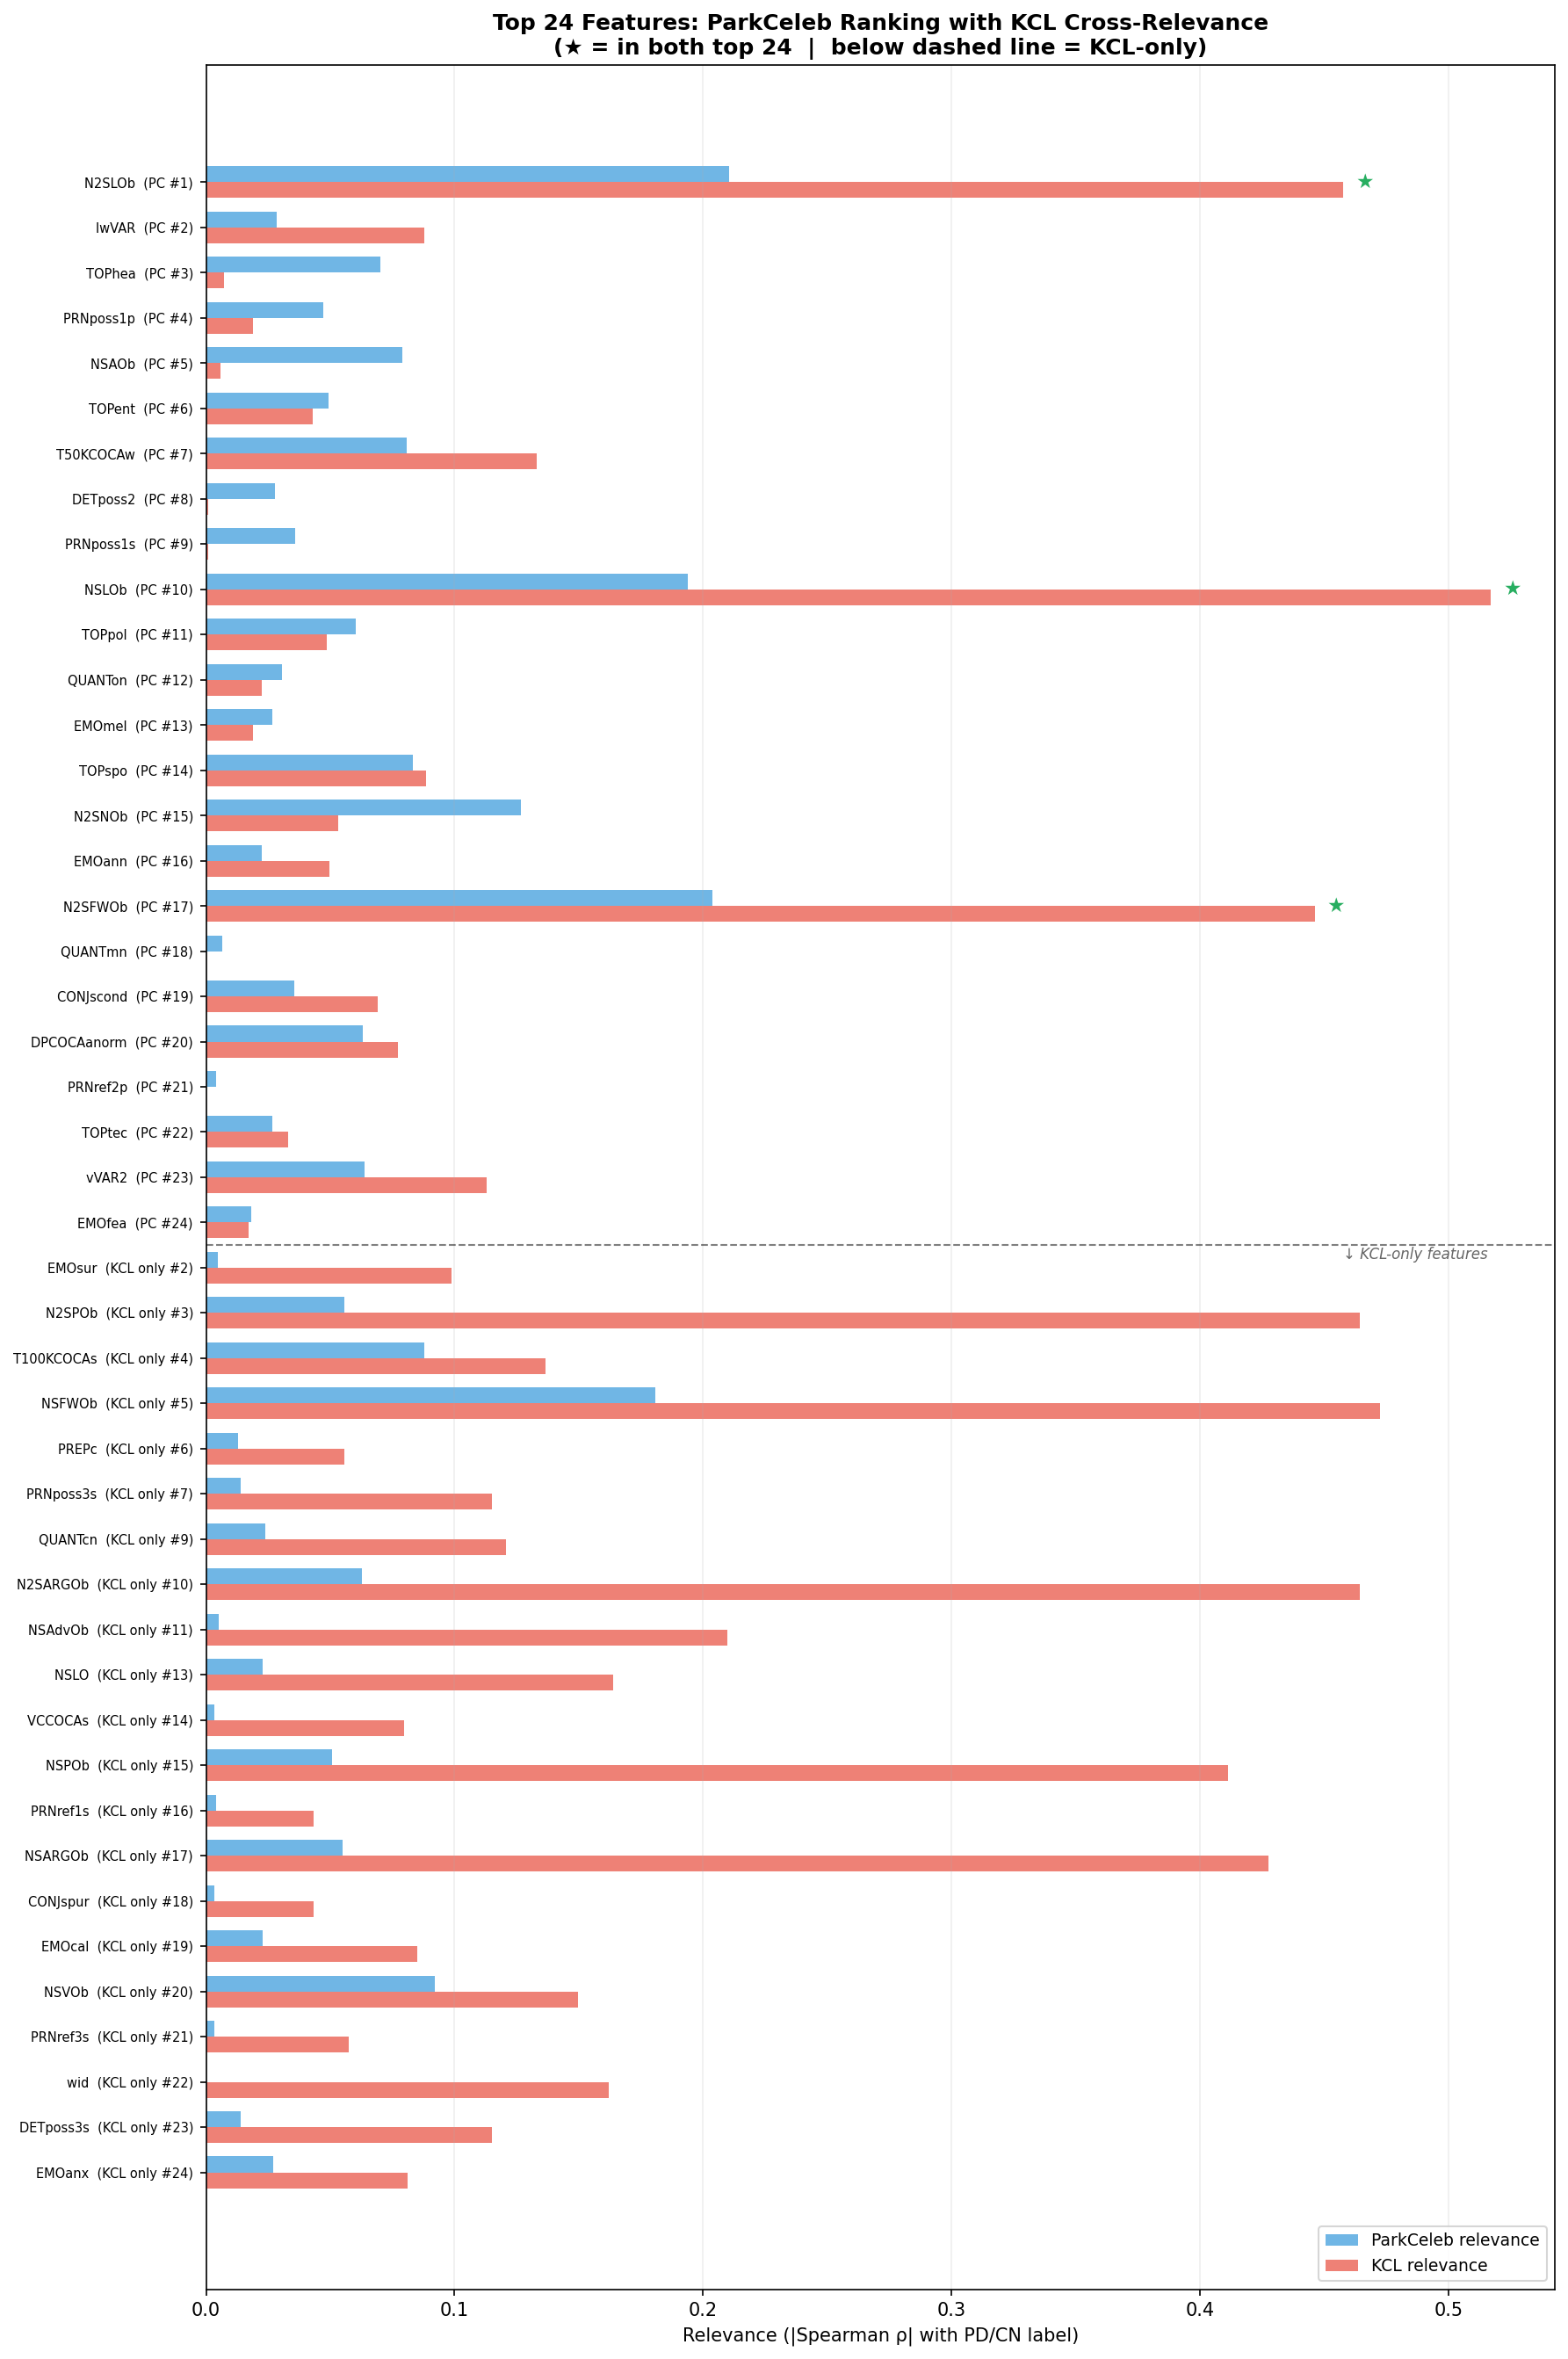


KEY INSIGHTS:
  Strong in both corpora: NSLOb, N2SFWOb, N2SLOb
    → Most transferable biomarkers
  Strong in PC, weak in KCL: TOPhea, NSAOb
    → May be corpus-specific, not generalisable
  Strong in KCL, not in PC top 24: EMOsur, N2SPOb, T100KCOCAs, NSFWOb, PREPc, PRNposs3s, QUANTcn, N2SARGOb, NSAdvOb, NSLO, VCCOCAs, NSPOb, NSARGOb, EMOcal, NSVOb, PRNref3s, wid, DETposs3s, EMOanx
    → Clinical speech may emphasise different markers


In [ ]:
# ============================================================
# 5.  Compare top N features: ParkCeleb vs KCL (cross-relevance)
# ============================================================

N_COMPARE = 24

# Run mRMR for both datasets
pc_top = run_mrmr(df, feature_cols, n_select=N_COMPARE)
kcl_top = run_mrmr(kcl, kcl_feat_cols, n_select=N_COMPARE) if kcl is not None else []

pc_names = [f for f, _, _, _ in pc_top]
kcl_names = [f for f, _, _, _ in kcl_top]

# Compute relevance of EVERY feature in BOTH datasets
y_pc = df['label'].values
y_kcl = kcl['label'].values

all_feats_union = list(dict.fromkeys(pc_names + kcl_names))

pc_relevance = {}
kcl_relevance = {}
for feat in all_feats_union:
    # ParkCeleb relevance
    if feat in df.columns and df[feat].std() > 1e-10:
        rho, _ = stats.spearmanr(df[feat].values, y_pc)
        pc_relevance[feat] = abs(rho) if not np.isnan(rho) else 0
    else:
        pc_relevance[feat] = 0
    
    # KCL relevance
    if kcl is not None and feat in kcl.columns and kcl[feat].std() > 1e-10:
        rho, _ = stats.spearmanr(kcl[feat].values, y_kcl)
        kcl_relevance[feat] = abs(rho) if not np.isnan(rho) else 0
    else:
        kcl_relevance[feat] = 0

# ---- Table: ParkCeleb top N with KCL relevance ----
print(f'PARKCELEB TOP {N_COMPARE} FEATURES — with KCL cross-relevance')
print(f'{"="*80}')
print(f'{"Rank":<5s} {"Feature":<35s} {"PC ρ":>8s} {"KCL ρ":>8s} {"In KCL top":>12s}')
print(f'{"─"*70}')
for i, feat in enumerate(pc_names):
    in_kcl = f'#{kcl_names.index(feat)+1}' if feat in kcl_names else '—'
    print(f'{i+1:<5d} {feat:<35s} {pc_relevance[feat]:>8.4f} {kcl_relevance[feat]:>8.4f} {in_kcl:>12s}')

# ---- Features in KCL top N but NOT in ParkCeleb top N ----
kcl_only = [f for f in kcl_names if f not in pc_names]
if kcl_only:
    print(f'\nKCL-ONLY FEATURES (in KCL top {N_COMPARE} but not ParkCeleb top {N_COMPARE})')
    print(f'{"─"*70}')
    print(f'{"KCL Rank":<10s} {"Feature":<35s} {"PC ρ":>8s} {"KCL ρ":>8s}')
    print(f'{"─"*70}')
    for feat in kcl_only:
        kcl_rank = kcl_names.index(feat) + 1
        print(f'{kcl_rank:<10d} {feat:<35s} {pc_relevance[feat]:>8.4f} {kcl_relevance[feat]:>8.4f}')

shared = set(pc_names) & set(kcl_names)
print(f'\nOverlap: {len(shared)}/{N_COMPARE} features shared')

# ---- Visual ----
# Show PC top N first, then KCL-only features below a divider
display_feats = pc_names + kcl_only
display_labels = [f'{f}  (PC #{i+1})' for i, f in enumerate(pc_names)] + \
                 [f'{f}  (KCL only #{kcl_names.index(f)+1})' for f in kcl_only]

fig, ax = plt.subplots(figsize=(12, max(6, len(display_feats) * 0.4)))

y_pos = np.arange(len(display_feats))
w = 0.35

pc_vals = [pc_relevance[f] for f in display_feats]
kcl_vals = [kcl_relevance[f] for f in display_feats]

bars1 = ax.barh(y_pos - w/2, pc_vals, w, label='ParkCeleb relevance', color='#3498DB', alpha=0.7)
bars2 = ax.barh(y_pos + w/2, kcl_vals, w, label='KCL relevance', color='#E74C3C', alpha=0.7)

# Mark shared features
for i, feat in enumerate(display_feats):
    if feat in shared:
        ax.annotate('★', xy=(max(pc_vals[i], kcl_vals[i]) + 0.005, i),
                   fontsize=11, color='#27AE60', fontweight='bold', va='center')

#Draw divider between PC features and KCL-only features
if kcl_only:
    divider_y = len(pc_names) - 0.5
    ax.axhline(divider_y, color='black', ls='--', lw=1, alpha=0.5)
    ax.text(ax.get_xlim()[1] * 0.95, divider_y + 0.3, '↓ KCL-only features',
            ha='right', fontsize=8, alpha=0.6, style='italic')

ax.set_yticks(y_pos)
ax.set_yticklabels(display_labels, fontsize=7)
ax.set_xlabel('Relevance (|Spearman ρ| with PD/CN label)')
ax.set_title(f'Top {N_COMPARE} Features: ParkCeleb Ranking with KCL Cross-Relevance\n'
             f'(★ = in both top {N_COMPARE}  |  below dashed line = KCL-only)')
ax.legend(fontsize=9, loc='lower right')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig('mrmr_cross_relevance.png', dpi=200, bbox_inches='tight')
plt.show()

# ---- Key insight summary ----
print(f'\nKEY INSIGHTS:')
# Features high in both
both_high = [f for f in shared if pc_relevance[f] > 0.05 and kcl_relevance[f] > 0.05]
if both_high:
    print(f'  Strong in both corpora: {", ".join(both_high)}')
    print(f'    → Most transferable biomarkers')

# Features high in PC but low in KCL
pc_high_kcl_low = [f for f in pc_names if kcl_relevance[f] < 0.03 and pc_relevance[f] > 0.05]
if pc_high_kcl_low:
    print(f'  Strong in PC, weak in KCL: {", ".join(pc_high_kcl_low)}')
    print(f'    → May be corpus-specific, not generalisable')

# Features high in KCL but not selected in PC
kcl_high_pc_low = [f for f in kcl_only if kcl_relevance[f] > 0.05]
if kcl_high_pc_low:
    print(f'  Strong in KCL, not in PC top {N_COMPARE}: {", ".join(kcl_high_pc_low)}')
    print(f'    → Clinical speech may emphasise different markers')

PARKCELEB TOP 24 FEATURES — with KCL cross-relevance
Rank  Feature                                 PC ρ    KCL ρ   In KCL top
──────────────────────────────────────────────────────────────────────
1     N2SLOb                                0.2106   0.4578           #8
2     lwVAR                                 0.0284   0.0878            —
3     TOPhea                                0.0702   0.0074            —
4     PRNposs1p                             0.0473   0.0190            —
5     NSAOb                                 0.0789   0.0060            —
6     TOPent                                0.0493   0.0428            —
7     T50KCOCAw                             0.0808   0.1332            —
8     DETposs2                              0.0277   0.0010            —
9     PRNposs1s                             0.0358   0.0009            —
10    NSLOb                                 0.1939   0.5170           #1
11    TOPpol                                0.0604   0.0484            —


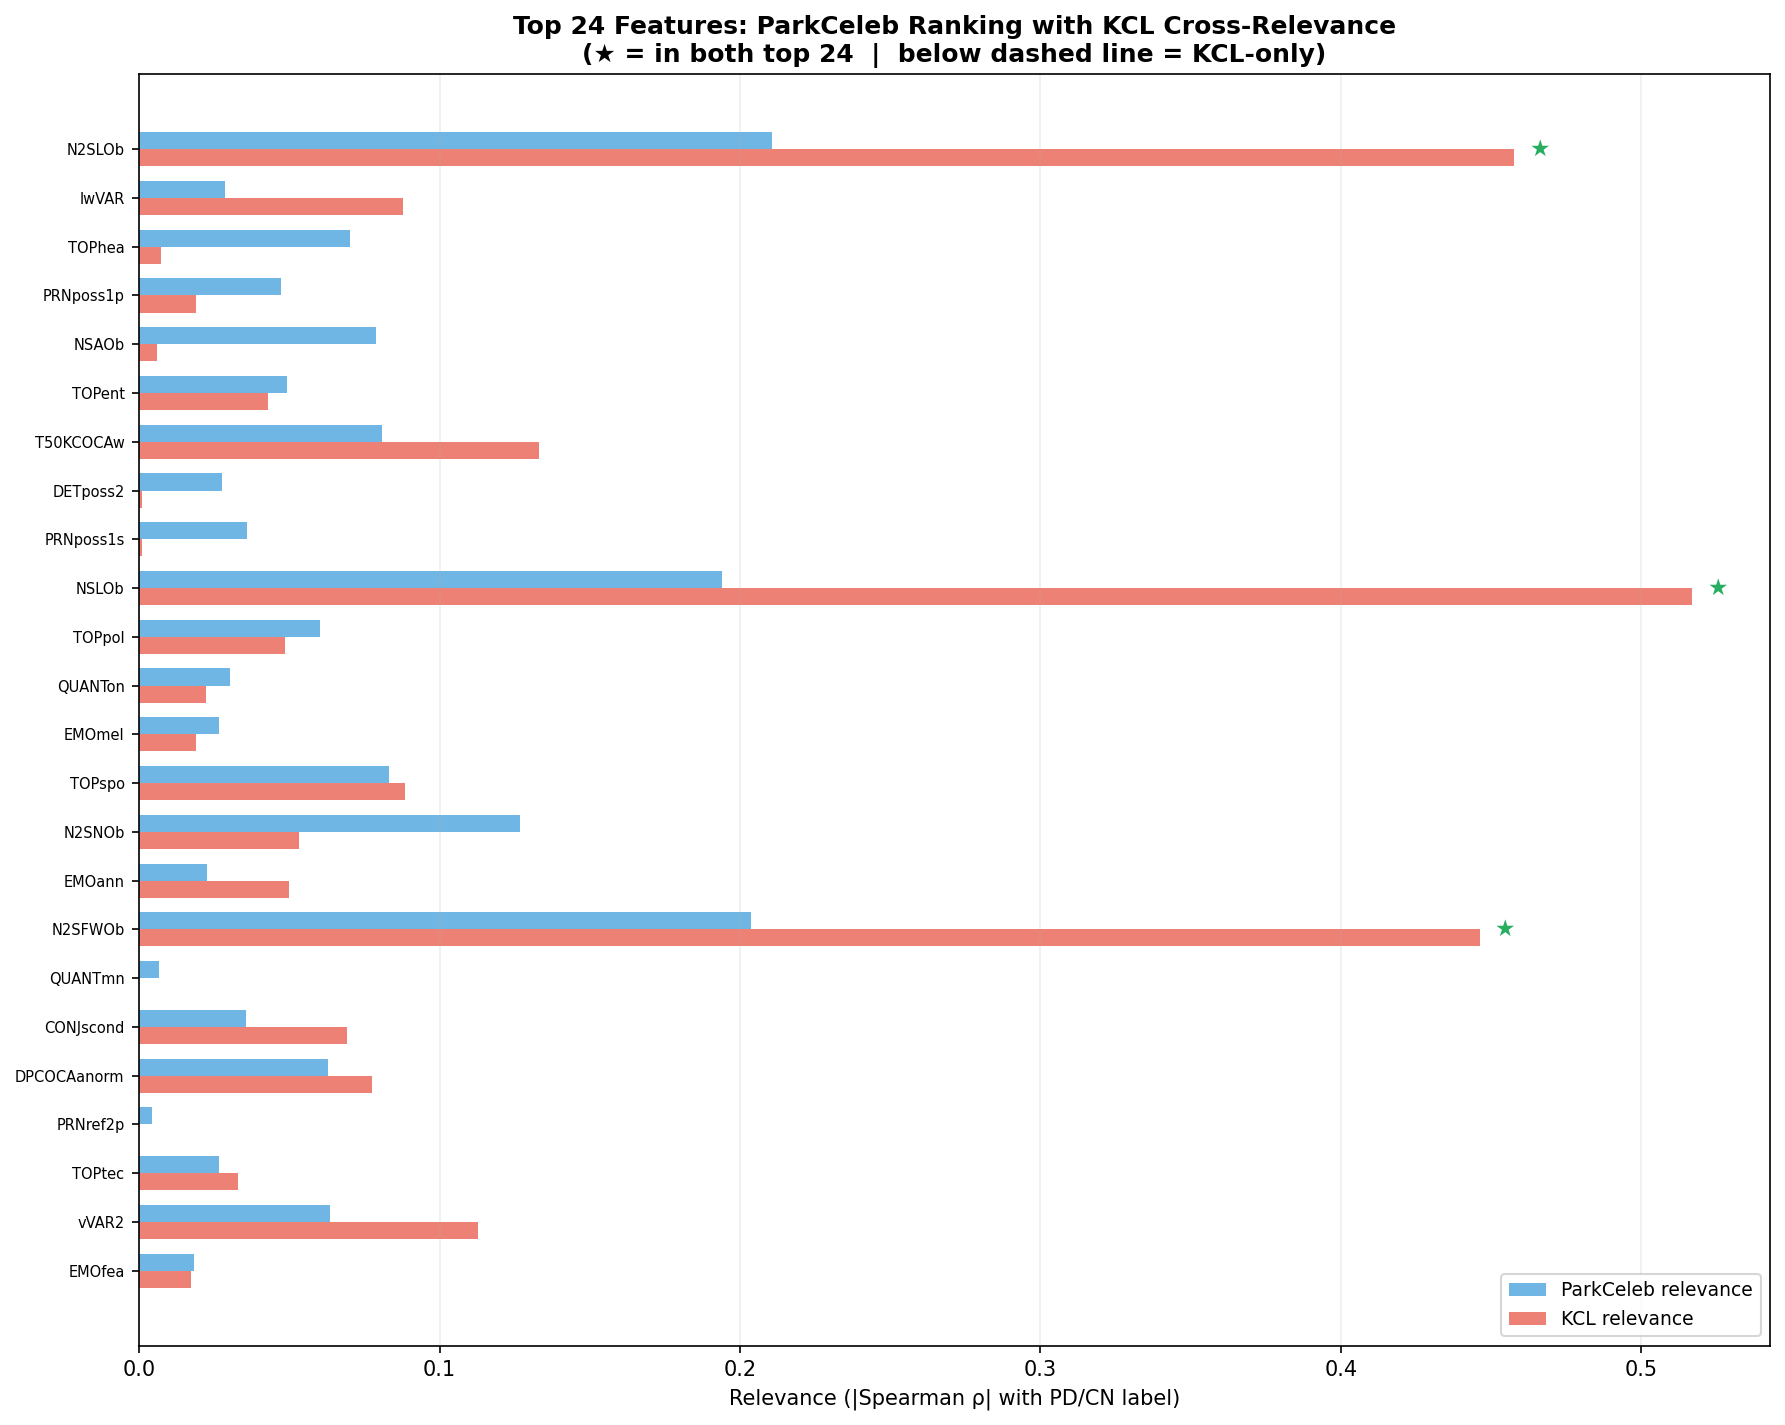

In [36]:
# ============================================================
# 5.  Compare top N features: ParkCeleb vs KCL (cross-relevance)
# ============================================================

N_COMPARE = 24

# Run mRMR for both datasets
pc_top = run_mrmr(df, feature_cols, n_select=N_COMPARE)
kcl_top = run_mrmr(kcl, kcl_feat_cols, n_select=N_COMPARE) if kcl is not None else []

pc_names = [f for f, _, _, _ in pc_top]
kcl_names = [f for f, _, _, _ in kcl_top]

# Compute relevance of EVERY feature in BOTH datasets
y_pc = df['label'].values
y_kcl = kcl['label'].values

all_feats_union = list(dict.fromkeys(pc_names + kcl_names))

pc_relevance = {}
kcl_relevance = {}
for feat in all_feats_union:
    # ParkCeleb relevance
    if feat in df.columns and df[feat].std() > 1e-10:
        rho, _ = stats.spearmanr(df[feat].values, y_pc)
        pc_relevance[feat] = abs(rho) if not np.isnan(rho) else 0
    else:
        pc_relevance[feat] = 0
    
    # KCL relevance
    if kcl is not None and feat in kcl.columns and kcl[feat].std() > 1e-10:
        rho, _ = stats.spearmanr(kcl[feat].values, y_kcl)
        kcl_relevance[feat] = abs(rho) if not np.isnan(rho) else 0
    else:
        kcl_relevance[feat] = 0

# ---- Table: ParkCeleb top N with KCL relevance ----
print(f'PARKCELEB TOP {N_COMPARE} FEATURES — with KCL cross-relevance')
print(f'{"="*80}')
print(f'{"Rank":<5s} {"Feature":<35s} {"PC ρ":>8s} {"KCL ρ":>8s} {"In KCL top":>12s}')
print(f'{"─"*70}')
for i, feat in enumerate(pc_names):
    in_kcl = f'#{kcl_names.index(feat)+1}' if feat in kcl_names else '—'
    print(f'{i+1:<5d} {feat:<35s} {pc_relevance[feat]:>8.4f} {kcl_relevance[feat]:>8.4f} {in_kcl:>12s}')



# ---- Visual ----
# Show PC top N first, then KCL-only features below a divider
display_feats = pc_names
display_labels = pc_names

fig, ax = plt.subplots(figsize=(12, max(6, len(display_feats) * 0.4)))

y_pos = np.arange(len(display_feats))
w = 0.35

pc_vals = [pc_relevance[f] for f in display_feats]
kcl_vals = [kcl_relevance[f] for f in display_feats]

bars1 = ax.barh(y_pos - w/2, pc_vals, w, label='ParkCeleb relevance', color='#3498DB', alpha=0.7)
bars2 = ax.barh(y_pos + w/2, kcl_vals, w, label='KCL relevance', color='#E74C3C', alpha=0.7)

# Mark shared features
for i, feat in enumerate(display_feats):
    if feat in shared:
        ax.annotate('★', xy=(max(pc_vals[i], kcl_vals[i]) + 0.005, i),
                   fontsize=11, color='#27AE60', fontweight='bold', va='center')



ax.set_yticks(y_pos)
ax.set_yticklabels(display_labels, fontsize=7)
ax.set_xlabel('Relevance (|Spearman ρ| with PD/CN label)')
ax.set_title(f'Top {N_COMPARE} Features: ParkCeleb Ranking with KCL Cross-Relevance\n'
             f'(★ = in both top {N_COMPARE}  |  below dashed line = KCL-only)')
ax.legend(fontsize=9, loc='lower right')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig('mrmr_cross_relevance.png', dpi=200, bbox_inches='tight')
plt.show()